In [1]:
import os
import numpy as np 
import matplotlib.pyplot as plt
from skimage.io import imread
import pydicom as dcm

In [2]:
#image_path = '/home/data/Mammo-MX/B1/000077_R_MLO_B1_D2'
image_path = '/home/data/Mammo-MX/B6/000457_L_MLO_B6_D3'
print(os.path.exists(image_path))

True


In [3]:
metadata = dcm.dcmread(image_path)

In [4]:
image = metadata.pixel_array

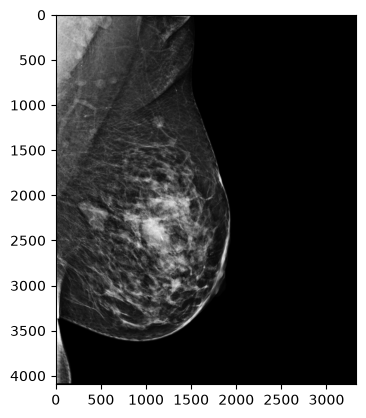

In [5]:
plt.imshow(image, cmap='gray')
plt.show()

In [6]:
import yaml

In [7]:
config = {}
with open("config.yaml") as stream:
    try:
        config = yaml.safe_load(stream)
    except yaml.YAMLError as exc:
        print(exc)

In [8]:
config

{'name': 'xAI',
 'model': 'resnet50',
 'weights': 'weights/best_model_resnet50_ft_full_1024.pth',
 'parameters': {'device_type': 'gpu',
  'gpu_number': 0,
  'input_size': [1024, 512],
  'num_classes': 2}}

In [9]:
from model import Model
from preprocessing import Preprocessing
from postprocessing import Postprocessing


In [10]:
# model_name = config['model']
model_name = 'efficientnetb0'
model_name = 'resnet50'

In [11]:
model = Model()
model.initialize_model(model_name)

In [12]:
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"

In [13]:
x = Preprocessing(image, dict(metadata), config).to(device)

In [14]:
y = model(x)

In [15]:
probs = Postprocessing(y)
print(probs)

[[0.46549878]]


In [16]:
from original_src.xai_explainability import ExplainabilityEngine, get_target_layer

In [17]:
print(model)

Model(
  (model): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
    

In [18]:
print(model.model.layer4)

Sequential(
  (0): Bottleneck(
    (conv1): Conv2d(1024, 512, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (bn1): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (conv2): Conv2d(512, 512, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (bn2): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (conv3): Conv2d(512, 2048, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (bn3): BatchNorm2d(2048, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (downsample): Sequential(
      (0): Conv2d(1024, 2048, kernel_size=(1, 1), stride=(2, 2), bias=False)
      (1): BatchNorm2d(2048, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    )
  )
  (1): Bottleneck(
    (conv1): Conv2d(2048, 512, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (bn1): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=T

In [19]:
target_layer = get_target_layer(model, model_name)
print(target_layer)

Getting target layer for model: resnet50
Bottleneck(
  (conv1): Conv2d(2048, 512, kernel_size=(1, 1), stride=(1, 1), bias=False)
  (bn1): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (conv2): Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn2): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (conv3): Conv2d(512, 2048, kernel_size=(1, 1), stride=(1, 1), bias=False)
  (bn3): BatchNorm2d(2048, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
)


In [20]:
xai_engine = ExplainabilityEngine(model=model, device = device, model_name=model_name)

In [21]:
# gradcam_attr = xai_engine.gradcam_attribution(x, target_layer)

In [ ]:
# Grad-CAM
#attr = xai_engine.gradcam_attribution(x, target_layer,target_class=0)

# Integrated Gradients
# attr = xai_engine.integrated_gradients_attribution(x, n_steps=30)

# Saliency
# attr = xai_engine.saliency_attribution(x, target_class=0)

# Shap 
attr = xai_engine.shap_attribution(x)

# Compare attributions
#attributions = {
    # 'Grad-CAM': gradcam_attr,
    # 'Integrated Gradients': ig_attr,
#    'Saliency': saliency_attr
#}

print(attr.shape)

In [ ]:
method_name = 'saliency'
idx = 1
xai_engine.show_attribution_map(
                    image,
                    attr,
                    title=f'{method_name} - Sample {idx}'
                )